In [105]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [82]:
df = pd.read_csv("powerplant_data.csv")

In [83]:
df.head(10)

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
5,13.97,39.16,1016.05,84.60,470.96
6,22.10,71.29,1008.20,75.38,442.35
7,14.47,41.76,1021.98,78.41,464.00
8,31.25,69.51,1010.25,36.83,428.77
9,6.77,38.18,1017.80,81.13,484.31


In [84]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [85]:
x = df.drop("PE" , axis =1)

In [86]:
y = df["PE"]

In [87]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [88]:
x_train, x_test, y_train, y_test = train_test_split(
        x,y, test_size = .2, random_state=42
    )

In [89]:
df.shape

(9568, 5)

In [90]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Prepareing TensorData

In [91]:
x_train_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [92]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Deep Learning

In [93]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # Hidden Layer 1
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),
            # Hidden Layer 2
            nn.Linear(6,6),
            nn.ReLU(),
            #Output Layer
            nn.Linear(6,1),
        )
    def forward(self, x):
        return self.model(x)
    

In [94]:
model = ANN()

In [95]:
# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

***For every batch:***

    Input Batch (feature_batch)
            ↓
    Forward Pass
            ↓
    Predictions
            ↓
    Loss Calculation
            ↓
    Backpropagation
            ↓
    Gradients
            ↓
    Adam Optimizer
            ↓
    Updated Weights

***For every epoch:***

    Train on all batches
            ↓
    Compute average train loss
            ↓
    Evaluate on validation set
            ↓
    Compute average validation loss
            ↓
    Save best model if improved

In [97]:
# Lists to store the training and validation losses for each epoch
train_loss = []
val_loss = []

best_val_loss = float("inf")

epochs = 100

for epoch in range (epochs):
    model.train()
    running_loss = 0.0

    for feature_batch, label_batch in train_loader:
        optimizer.zero_grad() # Remove the old value

        outputs = model(feature_batch)
        loss = criterion(outputs, label_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
    epoch_train_loss = running_loss / len(train_loader)
    train_loss.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for feature_batch, label_batch in test_loader:
            outputs = model(feature_batch)
            loss = criterion(outputs, label_batch)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_loss.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")
    
    

epoch 1/100 ==> train loss = 193231.95227864583 & val loss = 175444.39270833333
epoch 2/100 ==> train loss = 145503.40227864584 & val loss = 112367.44973958333
epoch 3/100 ==> train loss = 80973.40729166666 & val loss = 55218.84388020833
epoch 4/100 ==> train loss = 40411.98052571614 & val loss = 30647.741471354166
epoch 5/100 ==> train loss = 25359.956901041667 & val loss = 21690.42685546875
epoch 6/100 ==> train loss = 19178.76629638672 & val loss = 16970.814029947916
epoch 7/100 ==> train loss = 15032.459525553386 & val loss = 13129.537613932293
epoch 8/100 ==> train loss = 11392.778275553386 & val loss = 9543.984651692708
epoch 9/100 ==> train loss = 7970.280045572917 & val loss = 6446.802758789063
epoch 10/100 ==> train loss = 5222.905869547526 & val loss = 4135.282739257813
epoch 11/100 ==> train loss = 3333.8364822387693 & val loss = 2656.8391357421874
epoch 12/100 ==> train loss = 2147.078779602051 & val loss = 1742.1956176757812
epoch 13/100 ==> train loss = 1411.7826677958171

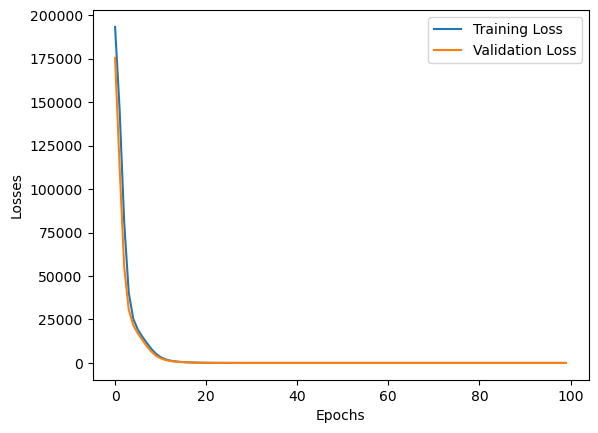

In [99]:
loss_df = pd.DataFrame({
    "Training Loss": train_loss,
    "Validation Loss": val_loss
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [102]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [103]:
print(model)

ANN(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=1, bias=True)
  )
)


## Evaluation

In [104]:
model.eval()
with torch.no_grad():
    train_preds = model(x_train_tensor)
    test_preds = model(x_test_tensor)
    
    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)  

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 21.22832489013672
Testing MSE: 19.54709815979004


In [106]:
print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9316879367119673


In [107]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.418854,433.27
1,437.033630,438.16
2,461.051636,458.42
3,475.892822,480.82
4,435.472778,441.41
...,...,...
1909,451.225189,456.70
1910,431.770111,438.04
1911,467.522766,467.80
1912,431.235992,437.14
